In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:

data = load_diabetes()

print("\nFeature names:")
print(data.feature_names)
print("\nDATA :")
print(data.data)




Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

DATA :
[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]


In [5]:
X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (353, 10)
Testing data: (89, 10)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
svr = SVR(
    kernel='rbf',
    C=1.0
)
svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [14]:

y_pred = svr.predict(X_test_scaled)

print("\nPredictions:")
print(y_pred[:10])



Predictions:
[142.35294557 142.76997294 141.79521687 152.15746672 136.80688143
 134.07634741 155.35932711 151.20907342 127.76202581 131.36919148]


In [15]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("\nEvaluation:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


Evaluation:
MAE : 56.0294733040062
MSE : 4332.738479345717
RMSE: 65.82354046498651
R2  : 0.18221699094239507


    What we choice in cross_val_score ke scoring parameter me 
    
    Classification →
    Accuracy / Precision / Recall / F1 / ROC-AUC

    Regression →
    R² / MAE / MSE / RMSE

In [17]:
scores = cross_val_score(
    svr,
    X_train_scaled,
    y_train,
    cv=10,
    scoring='r2'
)

print("Mean CV R2:", scores.mean())

Mean CV R2: 0.10012801695925196


In [18]:

kernels = ['linear', 'poly', 'rbf']

for kernel in kernels:

    model = SVR(
        kernel=kernel
    )

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    print(
        kernel,
        "R2 =",
        r2_score(y_test, pred)
    )

linear R2 = 0.44512484353785886
poly R2 = 0.28248427372271245
rbf R2 = 0.18221699094239507


In [25]:
param_grid = [

    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5, 1]
    },

    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5, 1],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto']
    },

    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5, 1],
        'gamma': ['scale', 'auto']
    }
]

In [30]:
grid = GridSearchCV(
    SVR(),
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Supp

In [31]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'epsilon': 0.01, 'kernel': 'linear'}
0.40744477125477696


In [32]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)


print("\nFinal Test Performance:")

print(
    "MAE :",
    mean_absolute_error(y_test, y_pred_best)
)

print(
    "MSE :",
    mean_squared_error(y_test, y_pred_best)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test, y_pred_best)
    )
)

print(
    "R2  :",
    r2_score(y_test, y_pred_best)
)




Final Test Performance:
MAE : 43.32911914076665
MSE : 2938.504648854249
RMSE: 54.20797587859418
R2  : 0.445371746915897


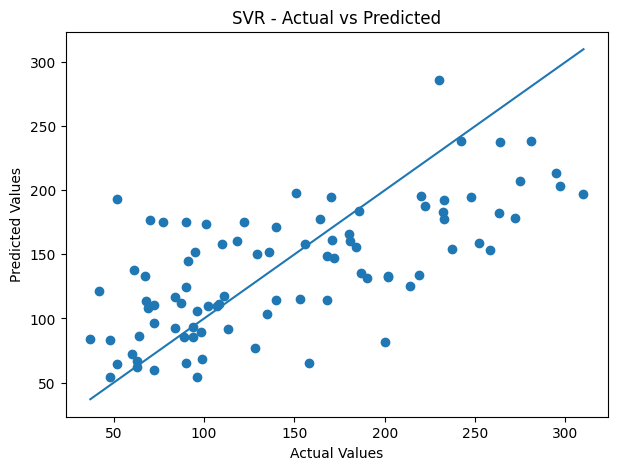

In [23]:
plt.figure(figsize=(7, 5))


best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
plt.scatter(
    y_test,
    y_pred_best
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("SVR - Actual vs Predicted")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [24]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1,
        gamma='scale'
    ))
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

print("\nPipeline R2:")
print(
    r2_score(
        y_test,
        pipeline_pred
    )
)


Pipeline R2:
0.4937125101265255
